In [184]:
import ast
import json
import re
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|') # NO TENEMOS QUE HACERLO DESPUES DEL SCRAPING ? 

# Extracción de datos

In [185]:
def extraer_informacion(url:str) -> list:
    '''
    Función para extraer la información relevante de la página de un anuncio.
    '''

    response = requests.get(url, timeout=10)
    soup = BeautifulSoup(response.text, 'html.parser')

    estate_component = soup.find("estate-show-v2")
    if not estate_component:
        return []
    
    estate_json_raw = estate_component.get(":estate")
    estate_json_raw = estate_json_raw.replace("&quot;", '"')
    estate_data = json.loads(estate_json_raw)

    data = {
        'dormitorios': estate_data.get('rooms'),
        'superficie_m2': estate_data.get('numeric_surface'),
        'baños': estate_data.get('bathrooms'),
        'url': estate_data.get('detail_url'),
        'features': estate_data.get('features'),
        'descripcion': estate_data.get('description'),
        'precio': estate_data.get('costs'),
        'latitud': estate_data.get('latitude'),
        'longitud': estate_data.get('longitude'),
        'media': estate_data.get('media'),
        'points_of_interest': estate_data.get('points_of_interest'),
        'energy_data': estate_data.get('energy_data'),
    }
    
    return data

In [186]:
def obtener_urls(url:str) -> list:
    '''
    Función para extraer la información relevante de la página de un anuncio.
    '''

    print(f'Buscando pisos en la página {url} ...')
    response = requests.get(url, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")

    estates_index = soup.find("estates-index")
    estates_raw = estates_index.get(":estates")
    estates_raw = estates_raw.replace("&quot;", '"')
    estates_data = json.loads(estates_raw)

    data = []

    for estate in estates_data:
        url_piso = estate.get("detail_url")

        if url_piso in df['url'].to_list():
            print('Ya lo tengo:', url_piso)
            return data
        data.append(extraer_informacion(url_piso))

    return data

In [187]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited))
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df])
df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/madrid/650140.html


# Pretratamiento de datos

In [188]:
# A partir de este punto sería interesante integrar un pipeline, para que si entra un nuevo piso todo se ejecute en el orden adecuado.

In [189]:
def _safe_eval(x):
    if isinstance(x, (dict, list)):
        return x
    if pd.isna(x):
        return {}
    s = str(x).strip()
    if s in ("", "{}", "[]", "None", "nan"):
        return {}
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def parse_nested_tecnocasa(X: pd.DataFrame) -> pd.DataFrame:
    df = X.copy()

    # 1) parseo seguro de columnas tipo dict/list que vienen como string
    for c in ["features", "precio", "media", "points_of_interest", "energy_data"]:
        if c in df.columns:
            df[c] = df[c].apply(_safe_eval)

    # 2) features
    if "features" in df.columns:
        f = df["features"]
        df["planta"] = f.apply(lambda d: d.get("floor"))
        df["aire_acondicionado"] = f.apply(lambda d: d.get("air_conditioning"))
        df["ascensor"] = f.apply(lambda d: d.get("elevator"))
        df["calefaccion"] = f.apply(lambda d: d.get("heating"))
        df["categoria"] = f.apply(lambda d: d.get("category"))
        df["año_construccion"] = f.apply(lambda d: d.get("build_year"))

    # 3) precio
    if "precio" in df.columns:
        p = df["precio"]
        df["precio_euros"] = p.apply(lambda d: d.get("price") if isinstance(d, dict) else np.nan)

        df["precio_euros"] = pd.to_numeric(p.apply(lambda d: d.get("price") if isinstance(d, dict) else np.nan)
                                           .astype(str).str.replace("€", "", regex=False).str.replace(" ", "", regex=False)
                                           .str.replace(".", "", regex=False).str.replace(",", ".", regex=False),errors="coerce" )
        df["hipoteca"] = p.apply(lambda d: d.get("mortgage_payment_value") if isinstance(d, dict) else np.nan).str.replace(".", "", regex=False).astype(int, errors="ignore")

    # 4) media
    if "media" in df.columns:
        m = df["media"]
        df["planos"] = m.apply(lambda d: d.get("floor_plans") is not None)
        df["realistico"] = m.apply(lambda d: d.get("has_realistico"))
        df["fotografias"] = m.apply(lambda d: len(d.get("images", [])) if isinstance(d.get("images", []), list) else 0)

    # 5) points_of_interest
    if "points_of_interest" in df.columns:
        poi = df["points_of_interest"]
        df["transporte_publico"] = poi.apply(lambda d: d.get("public_transport"))
        df["escuelas"] = poi.apply(lambda d: d.get("school"))
        df["farmacias"] = poi.apply(lambda d: d.get("pharmacy"))
        df["hospitales"] = poi.apply(lambda d: d.get("hospital"))
        df["supermercados"] = poi.apply(lambda d: d.get("market"))
        df["tiendas"] = poi.apply(lambda d: d.get("shop"))
        df["bares"] = poi.apply(lambda d: d.get("bar"))
        df["restaurantes"] = poi.apply(lambda d: d.get("restaurant"))

    # 6) energy_data
    if "energy_data" in df.columns:
        e = df["energy_data"]
        df["clase_energetica"] = e.apply(lambda d: d.get("class_emissions"))
        df["eficiencia_energetica"] = e.apply(lambda d: d.get("efficiency"))
        df["emisiones_energeticas"] = e.apply(lambda d: d.get("emissions"))

    return df


parse_step = FunctionTransformer(parse_nested_tecnocasa)

In [190]:
df = parse_nested_tecnocasa(df)

In [191]:
POI_MAP = {
    "transporte_publico": "tp",
    "escuelas": "esc",
    "farmacias": "fca",
    "hospitales": "hosp",
    "supermercados": "super",
    "tiendas": "tda",
    "bares": "bar",
    "restaurantes": "resto",
}

def _to_m(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    t = str(s).lower().replace(",", ".").replace(" ", "")
    if "km" in t:
        return float(t.replace("km", "")) * 1000
    if "m" in t:
        return float(t.replace("m", ""))
    return np.nan

def poi_features_tecnocasa(X: pd.DataFrame) -> pd.DataFrame:
    df = X.copy()

    for col, pref in POI_MAP.items():
        if col not in df.columns:
            continue

        df[f"{pref}_cnt"] = df[col].apply(lambda lst: len(lst) if lst else 0)

        df[f"{pref}_min_dist_m"] = df[col].apply(
            lambda lst: np.nan if not lst else min(
                _to_m(d.get("distance"))
                for d in lst
                if isinstance(d, dict) and d.get("distance")
            )
        )

    return df

poi_step = FunctionTransformer(poi_features_tecnocasa)

In [192]:
df = poi_features_tecnocasa(df)

In [193]:
def final_clean_tecnocasa(X: pd.DataFrame) -> pd.DataFrame:
    df = X.copy()

    # --- Dormitorios / baños: pasar a numérico ---
    if "dormitorios" in df.columns:
        df["dormitorios"] = (df["dormitorios"]
                             .astype(str)
                             .str.replace(r"\s*dorm\.", "", regex=True)
                             .str.strip())
        df["dormitorios"] = pd.to_numeric(df["dormitorios"], errors="coerce")

    if "baños" in df.columns:
        df["baños"] = (df["baños"]
                       .astype(str)
                       .str.replace(r"\s*baño[s]*", "", regex=True)
                       .str.strip())
        df["baños"] = pd.to_numeric(df["baños"], errors="coerce")

    # --- Planta: sacar paréntesis (ej: "3 (Exterior)" -> "3") ---
    if "planta" in df.columns:
        df["planta"] = (df["planta"]
                        .astype(str)
                        .str.replace(r"\s*\(.*\)", "", regex=True)
                        .str.strip())

    # --- Aire acondicionado: limpieza simple de texto ---
    if "aire_acondicionado" in df.columns:
        df["aire_acondicionado"] = (df["aire_acondicionado"]
                                    .astype(str)
                                    .str.replace(r"\s+.+", "", regex=True)
                                    .str.strip())

    # --- Calefacción: flags y limpieza ---
    if "calefaccion" in df.columns:
        cal = df["calefaccion"].astype(str)
        df["calefaccion_gas"] = cal.str.contains("gas", case=False, na=False)
        df["calefaccion_electrica"] = cal.str.contains("eléctrica|electrica", case=False, na=False)
        df["calefaccion"] = cal.str.replace(r"\s+.+", "", regex=True).str.strip()

    # --- Energía: limpiar comas / espacios raros ---
    if "eficiencia_energetica" in df.columns:
        s = df["eficiencia_energetica"].astype(str).str.lower().str.replace(",", ".", regex=False)
        df["eficiencia_energetica"] = pd.to_numeric(s.str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")

    if "emisiones_energeticas" in df.columns:
        df["emisiones_energeticas"] = (df["emisiones_energeticas"]
                                       .astype(str)
                                       .str.replace(",", ".", regex=False)
                                       .replace({"nan": np.nan, "None": np.nan, "": np.nan})).astype(float,errors="ignore")

    # --- Booleanos: asegurar 0/1 en ascensor, planos, etc. (si existen) ---
    for b in ["ascensor", "planos", "realistico", "calefaccion_gas", "calefaccion_electrica"]:
        if b in df.columns:
            df[b] = (
                df[b]
                .replace({"True": True, "False": False, "true": True, "false": False, "Sí": True, "Si": True, "No": False, "1": True, "0": False})
                .fillna(False)
                .astype(bool)
                .astype(int))

    
    df = df.replace({"None": np.nan, "nan": np.nan, "": np.nan, "NA": np.nan, "N/A": np.nan})

    return df

final_clean_step = FunctionTransformer(final_clean_tecnocasa)

In [194]:
df = final_clean_tecnocasa(df)

In [195]:
df_raw = pd.read_csv('../data/pisos_madrid.csv', sep ='|')

DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
)

In [196]:
pipe_features = Pipeline([
    ("parse_nested", parse_step),        # crea transporte_publico, escuelas, precio_euros, etc.
    ("poi_features", poi_step),          # crea tp_cnt, tp_min_dist_m, esc_cnt, ...
    ("final_clean", final_clean_step),   # regex, flags, booleans, normalización de NaN
    ("drop",drop_step)
])

df_feat = pipe_features.fit_transform(df_raw)

In [197]:
df_feat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dormitorios            1097 non-null   float64
 1   superficie_m2          1208 non-null   float64
 2   baños                  1112 non-null   float64
 3   latitud                1208 non-null   float64
 4   longitud               1208 non-null   float64
 5   planta                 761 non-null    str    
 6   aire_acondicionado     452 non-null    str    
 7   ascensor               1208 non-null   int64  
 8   calefaccion            669 non-null    str    
 9   categoria              1208 non-null   str    
 10  año_construccion       1208 non-null   int64  
 11  precio_euros           1208 non-null   int64  
 12  hipoteca               1208 non-null   int64  
 13  planos                 1208 non-null   int64  
 14  realistico             1208 non-null   int64  
 15  fotografias    

In [198]:
df_feat.head(3)

,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,categoria,año_construccion,precio_euros,hipoteca,planos,realistico,fotografias,clase_energetica,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica
0,1.0,44.0,1.0,40.393902,-3.660942,2,NaN,0,NaN,Popular,1920,155000,499,0,0,9,e,220.0,29,5,90.0,5,90.0,5,90.0,3,2500.0,5,50.0,5,100.0,5,250.0,5,300.0,0,0
1,NaN,106.0,1.0,40.398502,-3.651372,5,Independiente,1,Independiente,Popular,1981,270000,870,0,0,18,d,220.0,28.4,5,60.0,5,180.0,5,170.0,4,2500.0,5,500.0,5,550.0,5,420.0,5,370.0,0,0
2,1.0,84.0,1.0,40.333302,-3.525622,NaN,Independiente,0,NaN,Media,2007,230000,741,0,0,16,NaN,NaN,NaN,4,790.0,5,890.0,3,900.0,2,660.0,5,250.0,5,230.0,5,380.0,5,390.0,0,0


In [199]:
# Separar en X_train, X_test, y_train , y_test
# Otro pipeline

In [200]:
coordenadas = df[['latitud','longitud']]

In [201]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
coords = scaler.fit_transform(coordenadas)

In [202]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

ks = []
inertias = []
sil_scores = []
k_range = range(2,12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
    kmeans.fit(coords)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(coordenadas, kmeans.labels_))
    ks.append(k)
    
    

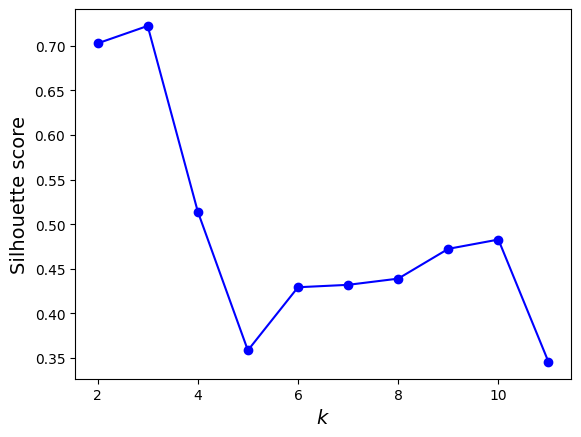

In [203]:
plt.plot(ks, sil_scores, "bo-");
plt.xlabel("$k$", fontsize=14);
plt.ylabel("Silhouette score", fontsize=14);

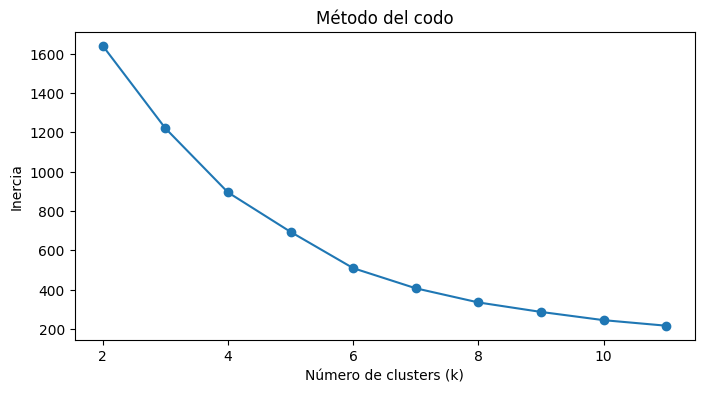

In [204]:
plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

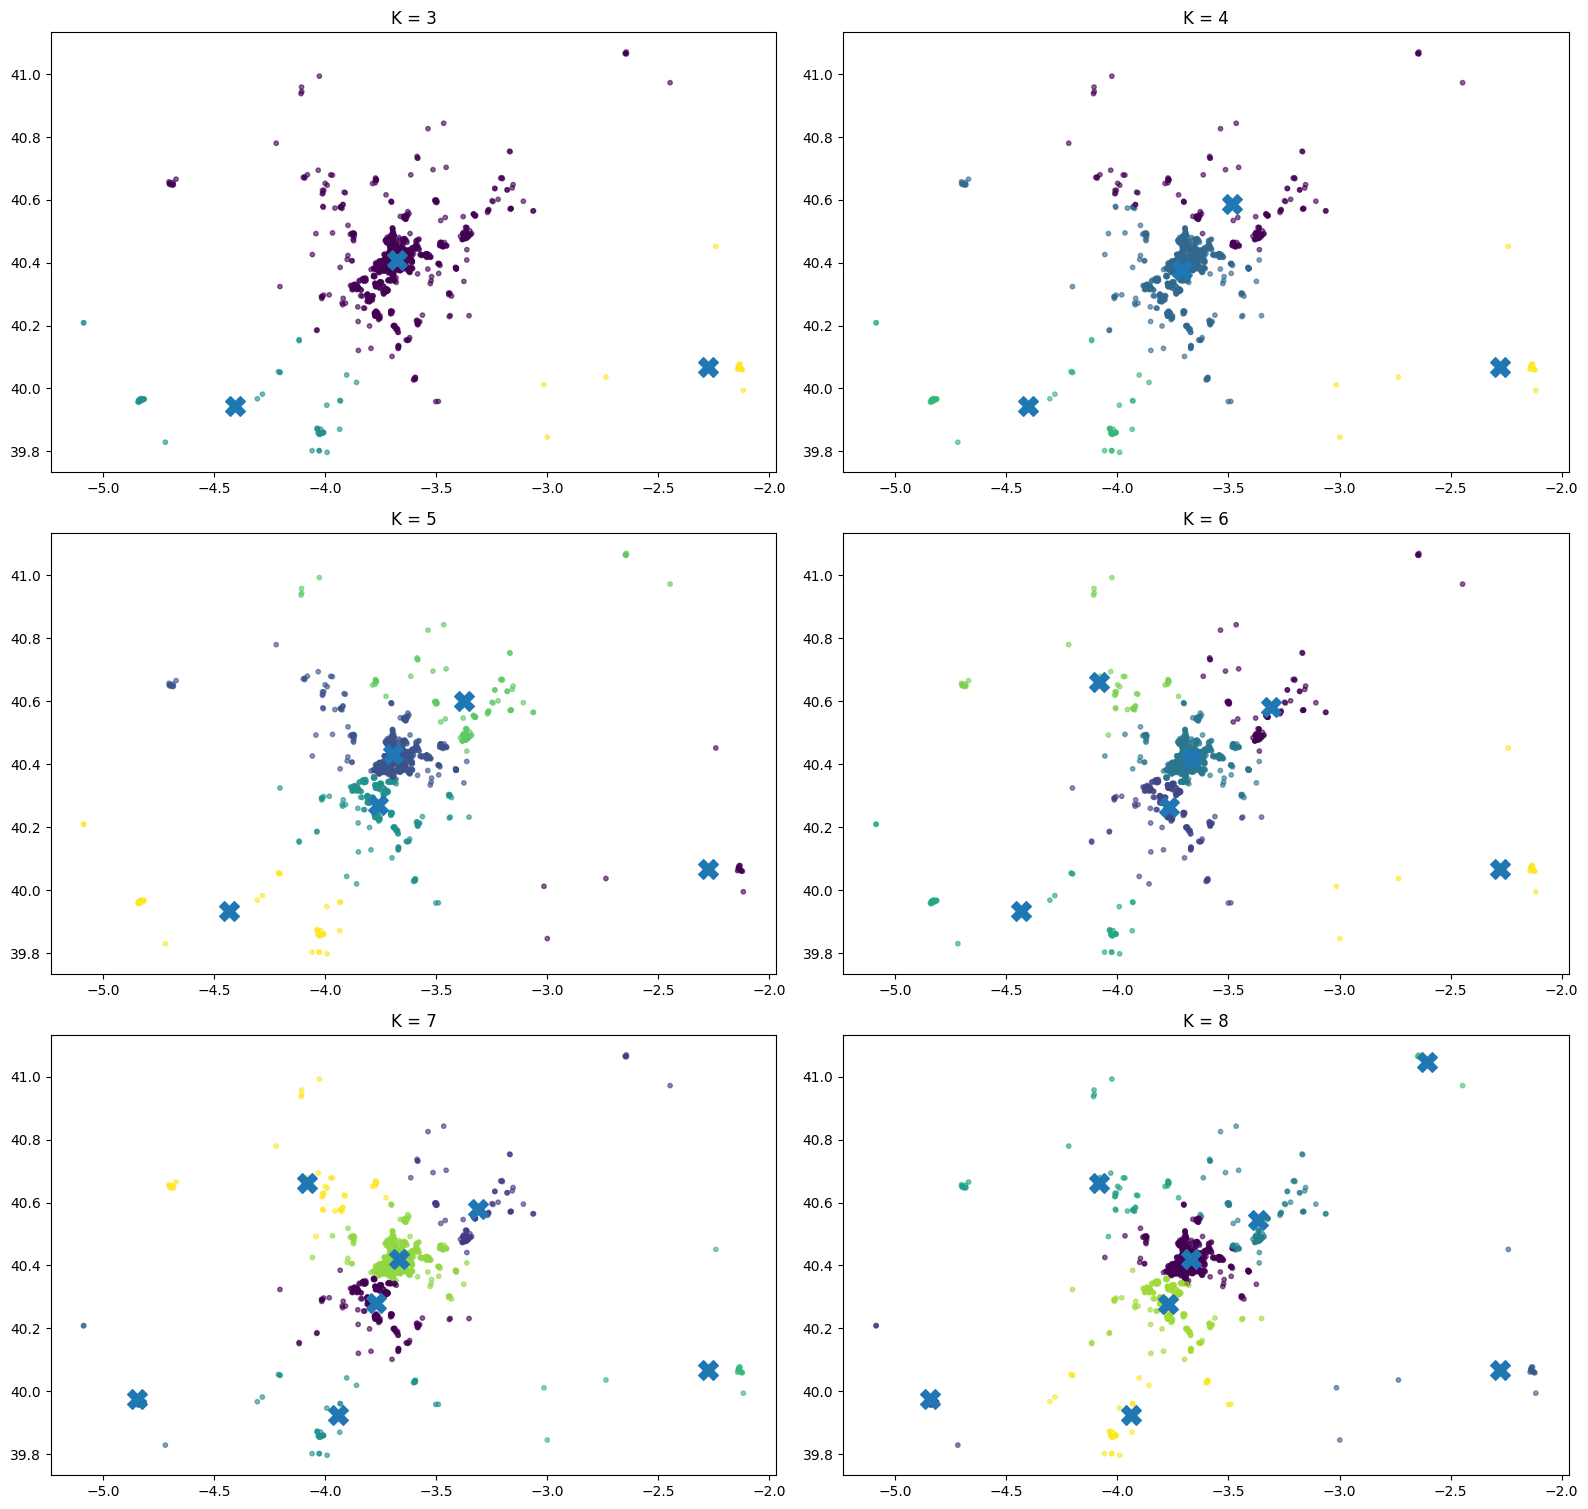

In [205]:
k_values = [3,4,5,6,7,8]

plt.figure(figsize=(16,30))

for i, k in enumerate(k_values):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(coords)
    
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    plt.subplot(6,2,i+1)

    plt.scatter(
        df['longitud'],
        df['latitud'],
        c=labels,
        s=10,
        alpha=0.6
    )

    plt.scatter(
        centroids[:,1],
        centroids[:,0],
        marker='X',
        s=200
    )

    plt.title(f"K = {k}")

plt.tight_layout()
plt.show()

In [206]:
k = 5

In [207]:
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=50)
kmeans_final.fit(coords)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",50
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [208]:
clusters = kmeans_final.predict(coords)
for i in range(k):
    df[f'cluster_{i}'] = (clusters == i).astype(int)

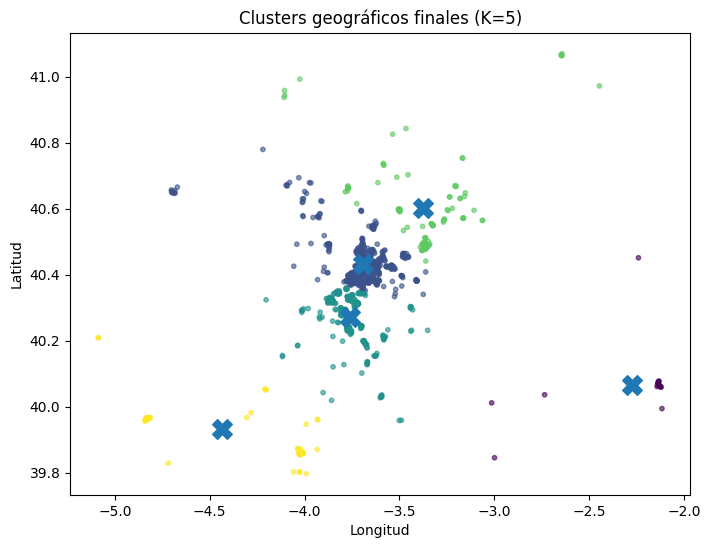

In [209]:
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    df['longitud'],
    df['latitud'],
    c=clusters,
    s=10,
    alpha=0.6
)

plt.scatter(
    centroids[:,1],
    centroids[:,0],
    marker='X',
    s=200
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Clusters geográficos finales (K={k})")
plt.show()

In [ ]:
df[["cluster_0", "cluster_1", "cluster_2", "cluster_3", "cluster_4"]].sample(5)

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
759,0,1,0,0,0
419,0,1,0,0,0
665,0,1,0,0,0
137,0,0,1,0,0
642,0,1,0,0,0


In [211]:
df.to_csv("../data/df_geo_clusters.csv", index=False)